## 2413998 Pratik Shrestha

# Worksheet 1

## Exercise 1

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

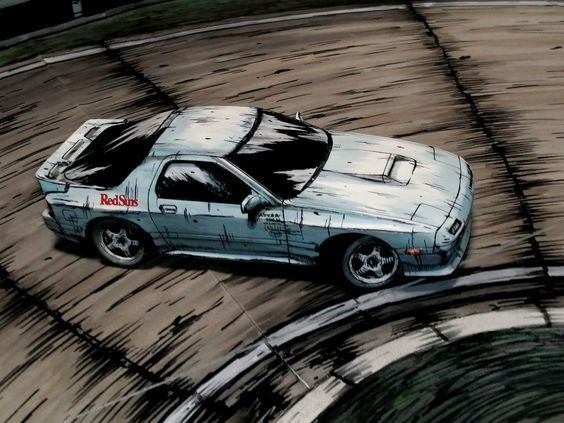

In [2]:
image = Image.open('/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 1/fc.jpg')
display(image)

In [3]:
print(len( image . getbands () ))

3


In [4]:
image_array = np.array(image)

array([[[ 50,  69,  63],
        [ 56,  75,  69],
        [ 64,  83,  77],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 62,  81,  75],
        [ 63,  82,  76],
        [ 63,  82,  76],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 68,  85,  79],
        [ 66,  83,  77],
        [ 64,  81,  75],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[ 34,  29,  23],
        [ 40,  35,  29],
        [ 48,  43,  37],
        ...,
        [ 93,  85,  74],
        [ 95,  87,  76],
        [ 98,  90,  79]],

       [[ 47,  42,  36],
        [ 56,  51,  45],
        [ 65,  60,  54],
        ...,
        [ 91,  83,  72],
        [ 85,  77,  66],
        [ 87,  79,  68]],

       [[ 59,  54,  48],
        [ 57,  52,  46],
        [ 54,  49,  43],
        ...,
        [103,  95,  84],
        [103,  95,  84],
        [ 84,  76,  65]]], dtype=uint8)
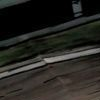

In [5]:
top_left = image_array[0:100,0:100]
display(top_left)

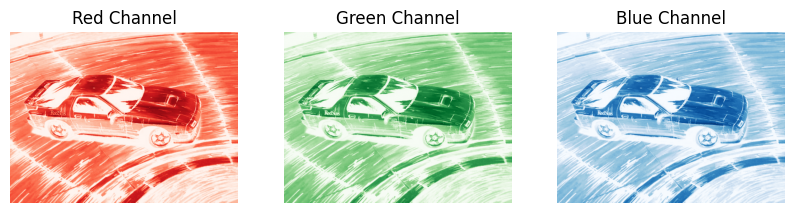

In [6]:
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

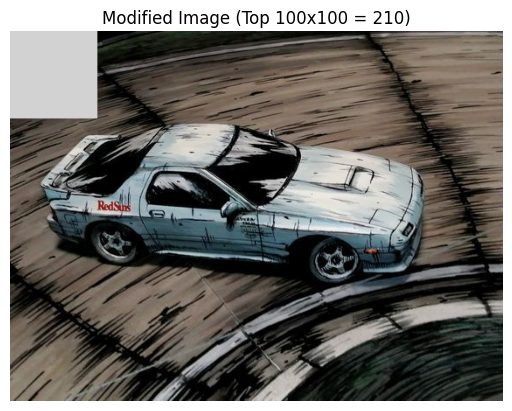

In [7]:
# Modified image with top left corner gray
modified = image_array.copy()
modified[0:100, 0:100] = 210
plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

## Exercise 2

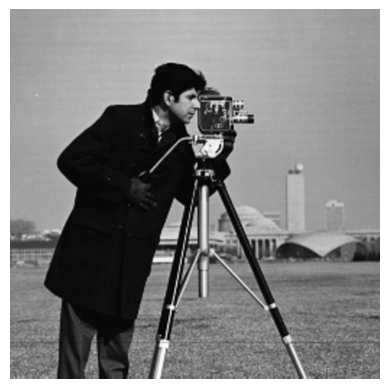

In [8]:
img_grayscale = Image.open('/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 1/cameraman.png')
plt.imshow(img_grayscale, cmap='gray')
plt.axis("off")
plt.show()

In [9]:
img_array = np.array(img_grayscale)
print(img_array.shape)

(512, 512)


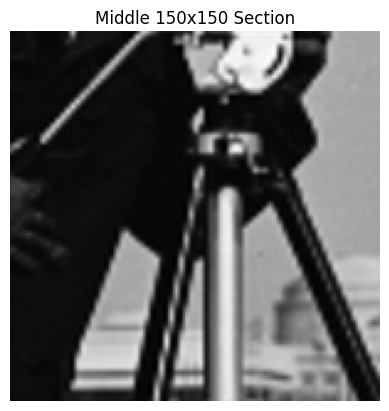

In [10]:
h,w = img_array.shape
center_h = h//2
center_w = w//2
middle_section = img_array[center_h-75:center_h+75, center_w-75:center_w+75]
plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

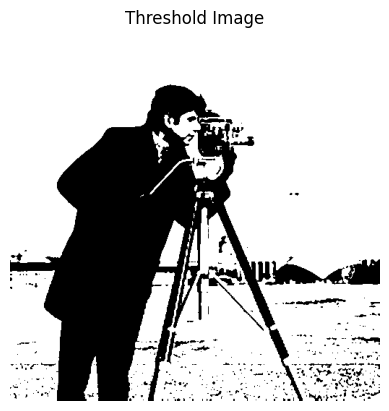

In [11]:
binary_image = img_array.copy()
binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255
plt.imshow(binary_image, cmap="gray")
plt.title("Threshold Image")
plt.axis("off")
plt.show()

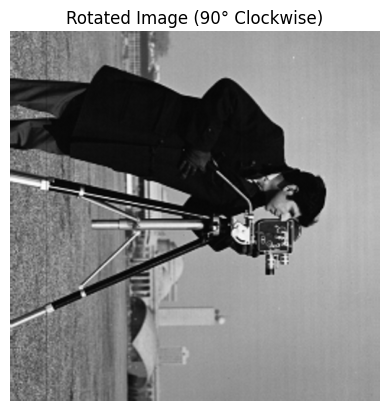

In [12]:
rotated_image = img_grayscale.rotate(-90)
plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

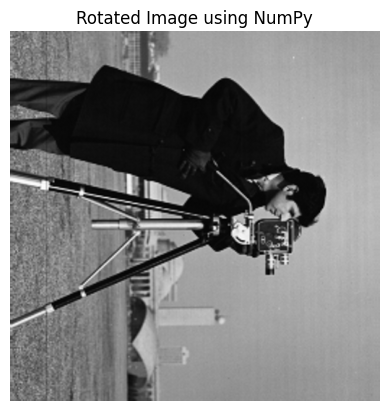

In [13]:
rotated_array = np.rot90(img_array, -1)
plt.imshow(rotated_array, cmap="gray")
plt.title("Rotated Image using NumPy")
plt.axis("off")
plt.show()

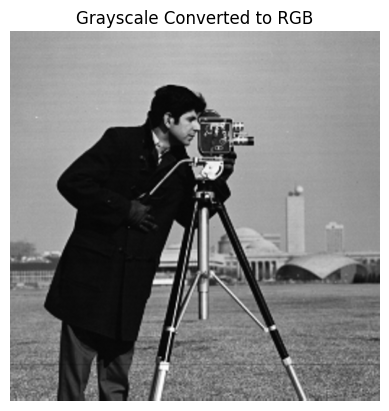

In [14]:
rgb_image = np.stack((img_array,)*3, axis=-1)
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

In [15]:
image_from_array = Image.fromarray(rgb_image)
print(image_from_array.getbands())

('R', 'G', 'B')


## Exercise 3

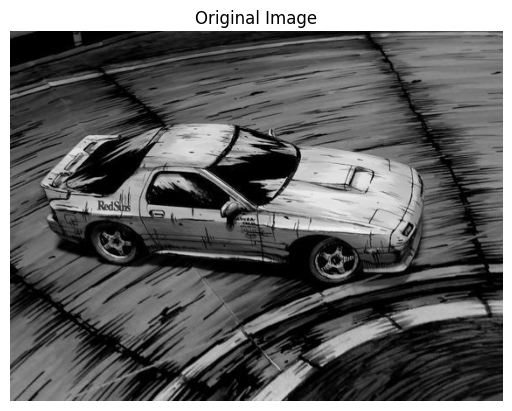

In [33]:
#Converting to grayscale
image = Image.open('/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 1/fc.jpg').convert("L")
img_array = np.array(image, dtype=float)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [34]:
print(img_array.shape)

(423, 564)


In [35]:
height,width = img_array.shape
data = img_array.reshape(height,width)

In [36]:
mean = np.mean(data, axis=0)
centered_data = data - mean

In [37]:
cov_matrix = np.cov(centered_data, rowvar=False)

In [38]:
# Computing eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [39]:
# Sorting eigen values and vectors in descending order
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

In [40]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


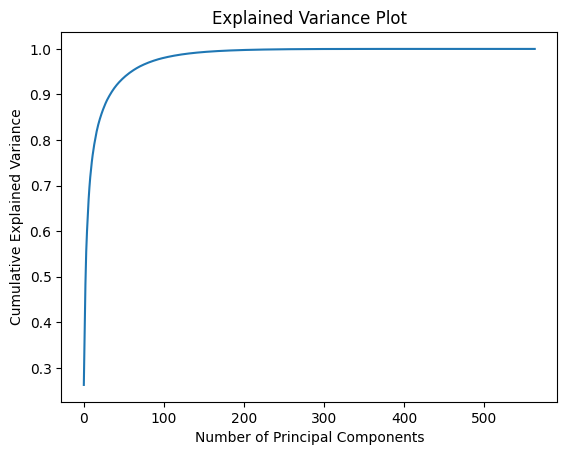

In [41]:
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.show()

In [42]:
k = 100
components = sorted_eigenvectors [: , : k ]

In [43]:
compressed_data = np . dot ( centered_data , components )

In [44]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

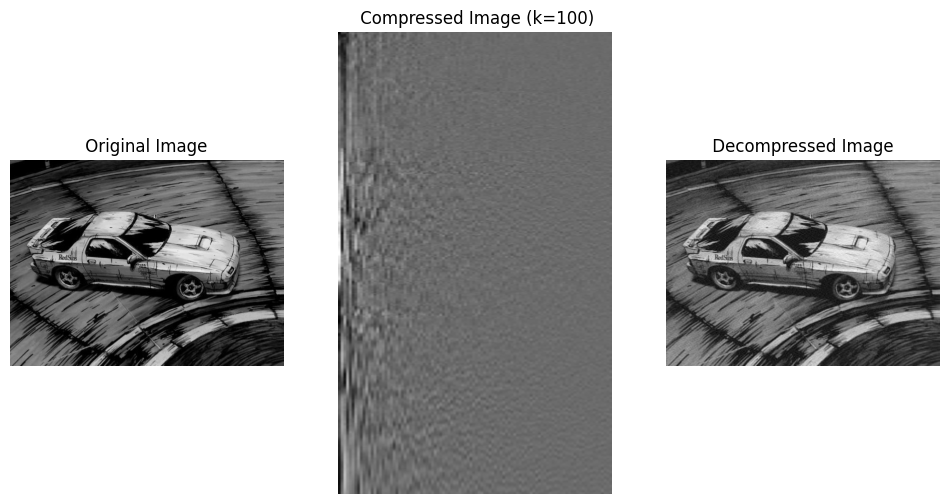

In [46]:
plt.figure ( figsize =(12 , 6) )
# Original Image
plt.subplot (1 , 3 , 1)
plt.imshow ( img_array , cmap ="gray")
plt.title (" Original Image ")
plt.axis ("off")
# Compressed Representation
plt.subplot (1 , 3 , 2)
plt.imshow (compressed_data.real, cmap ="gray", aspect ="auto")
plt.title ( f" Compressed Image (k={k})")
plt.axis ("off")
# Decompressed Image
plt.subplot (1 , 3 , 3)
plt.imshow ( decompressed_data.real , cmap ="gray")
plt.title (" Decompressed Image ")
plt.axis ("off")

plt.show()